In [1]:
# ============================================================
# PAPER PLOT TEMPLATE - BLACK & WHITE VERSION
# Dùng cho bài báo khoa học / đồ án / luận văn
# ============================================================
#
# Mục tiêu:
#   - Tất cả biểu đồ có cùng style.
#   - In đen trắng vẫn rõ.
#   - Font chung Times New Roman.
#   - Chuỗi thời gian nét mảnh, màu đen.
#   - Histogram xám nhạt, viền đen.
#   - Nhiều chuỗi phân biệt bằng kiểu nét, không phụ thuộc màu.
#
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import os
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CẤU HÌNH CHUNG
# ============================================================

PAPER_STYLE = {
    # --------------------------------------------------------
    # Kích thước hình
    # --------------------------------------------------------
    "single_col": (6.0, 3.4),
    "double_col": (7.2, 4.0),

    # --------------------------------------------------------
    # Font
    # --------------------------------------------------------
    "font_family": "serif",
    "font_serif": ["Times New Roman", "Times", "DejaVu Serif"],

    "font_size": 11,
    "title_size": 12,
    "label_size": 11,
    "tick_size": 10,
    "legend_size": 10,

    # --------------------------------------------------------
    # Màu đen trắng
    # --------------------------------------------------------
    "main_color": "black",
    "hist_facecolor": "0.85",      # xám nhạt
    "hist_edgecolor": "black",
    "bar_facecolor": "0.75",       # xám vừa
    "bar_edgecolor": "black",
    "scatter_facecolor": "0.80",
    "scatter_edgecolor": "black",

    # --------------------------------------------------------
    # Đường nét
    # --------------------------------------------------------
    "line_width": 0.9,
    "thick_line_width": 1.2,
    "marker_size": 4,
    "scatter_size": 24,

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------
    "grid": True,
    "grid_alpha": 0.20,
    "grid_linewidth": 0.5,

    # --------------------------------------------------------
    # Xuất file
    # --------------------------------------------------------
    "dpi": 500,
    "format": "png",              # có thể đổi thành "pdf", "svg"
    "bbox_inches": "tight",

    # --------------------------------------------------------
    # Kiểu nét khi vẽ nhiều chuỗi
    # --------------------------------------------------------
    "line_styles": ["-", "--", "-.", ":"],
    "hatches": [None, "//", "\\\\", "..", "xx"],
}


# ============================================================
# 2. HÀM ÁP DỤNG STYLE
# ============================================================

def set_paper_style(style=PAPER_STYLE):
    """
    Áp dụng style chung cho toàn bộ biểu đồ.

    Gọi hàm này trước khi vẽ.
    Các hàm vẽ bên dưới đã tự gọi hàm này.
    """

    plt.rcParams.update({
        # Font
        "font.family": style["font_family"],
        "font.serif": style["font_serif"],
        "font.size": style["font_size"],

        # Tiêu đề và nhãn trục
        "axes.titlesize": style["title_size"],
        "axes.labelsize": style["label_size"],
        "axes.linewidth": 0.8,

        # Tick
        "xtick.labelsize": style["tick_size"],
        "ytick.labelsize": style["tick_size"],
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,

        # Legend
        "legend.fontsize": style["legend_size"],
        "legend.frameon": False,

        # Figure
        "figure.dpi": style["dpi"],
        "savefig.dpi": style["dpi"],

        # Bỏ khung trên và phải
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Công thức toán
        "mathtext.fontset": "stix",
    })


def format_axis(
    ax,
    title=None,
    xlabel=None,
    ylabel=None,
    xlim=None,
    ylim=None,
    legend=True,
    grid=True,
    style=PAPER_STYLE
):
    """
    Chuẩn hóa trục, tiêu đề, nhãn, grid và legend.
    """

    if title is not None:
        ax.set_title(title, pad=10)

    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=6)

    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=6)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    if grid and style["grid"]:
        ax.grid(
            True,
            alpha=style["grid_alpha"],
            linewidth=style["grid_linewidth"]
        )

    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if len(labels) > 0:
            ax.legend()

    return ax


def save_figure(fig, filename, folder="figures", style=PAPER_STYLE):
    """
    Lưu hình theo chuẩn thống nhất.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure cần lưu.

    filename : str
        Tên file, không cần ghi đuôi.

    folder : str
        Thư mục lưu hình.
    """

    os.makedirs(folder, exist_ok=True)

    file_format = style["format"]
    path = os.path.join(folder, f"{filename}.{file_format}")

    fig.savefig(
        path,
        dpi=style["dpi"],
        bbox_inches=style["bbox_inches"]
    )

    return path


# ============================================================
# 3. HÀM XỬ LÝ DỮ LIỆU ĐẦU VÀO
# ============================================================

def to_1d_array(x):
    """
    Chuyển dữ liệu về numpy array một chiều và loại bỏ giá trị thiếu.
    """

    arr = np.asarray(x)
    arr = arr.reshape(-1)
    arr = arr[~pd.isna(arr)]

    return arr


def align_xy(x, y):
    """
    Căn chỉnh hai biến x, y và loại bỏ các quan sát bị thiếu.

    Dùng cho scatter plot, hồi quy tuyến tính, kiểm tra phụ thuộc.
    """

    df = pd.DataFrame({
        "x": x,
        "y": y
    }).dropna()

    return df["x"].to_numpy(), df["y"].to_numpy()


def normal_pdf(x, mu, sigma):
    """
    Hàm mật độ xác suất của phân phối chuẩn.

    Công thức:

        f(x) = 1 / (sigma * sqrt(2*pi))
               * exp( -0.5 * ((x - mu) / sigma)^2 )

    Không dùng scipy để giữ code nhẹ và rõ công thức.
    """

    z = (x - mu) / sigma

    pdf = (
        1.0 / (sigma * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * z ** 2)
    )

    return pdf


# ============================================================
# 4. BIỂU ĐỒ CHUỖI THỜI GIAN
# ============================================================

def plot_time_series(
    data,
    x_col,
    y_col,
    title=None,
    xlabel="Time",
    ylabel=None,
    label=None,
    filename=None,
    folder="figures",
    figsize=None,
    show_zero_line=False
):
    """
    Vẽ một chuỗi thời gian.

    Phù hợp cho:
        - Giá cổ phiếu
        - Lợi suất
        - Tổn thất
        - VaR rolling
        - ES rolling

    Parameters
    ----------
    data : pandas.DataFrame
        Dữ liệu.

    x_col : str
        Tên cột thời gian.

    y_col : str
        Tên cột giá trị.

    show_zero_line : bool
        Nếu True, vẽ thêm đường ngang y = 0.
    """

    set_paper_style()

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        data[x_col],
        data[y_col],
        color=PAPER_STYLE["main_color"],
        linewidth=PAPER_STYLE["line_width"],
        label=label if label is not None else y_col
    )

    if show_zero_line:
        ax.axhline(
            y=0,
            color="black",
            linewidth=0.7,
            linestyle="--",
            alpha=0.8
        )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel if ylabel is not None else y_col,
        legend=True
    )

    fig.autofmt_xdate()

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 5. BIỂU ĐỒ NHIỀU CHUỖI THỜI GIAN
# ============================================================

def plot_multi_series(
    data,
    x_col,
    y_cols,
    title=None,
    xlabel="Time",
    ylabel=None,
    labels=None,
    filename=None,
    folder="figures",
    figsize=None,
    show_zero_line=False
):
    """
    Vẽ nhiều chuỗi trên cùng một hệ trục.

    Vì in đen trắng, các chuỗi được phân biệt bằng kiểu nét:
        - nét liền
        - nét đứt
        - chấm gạch
        - chấm

    Không dùng màu để phân biệt.
    """

    set_paper_style()

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    if labels is None:
        labels = y_cols

    fig, ax = plt.subplots(figsize=figsize)

    line_styles = PAPER_STYLE["line_styles"]

    for i, (y_col, label) in enumerate(zip(y_cols, labels)):
        ax.plot(
            data[x_col],
            data[y_col],
            color="black",
            linestyle=line_styles[i % len(line_styles)],
            linewidth=PAPER_STYLE["line_width"],
            label=label
        )

    if show_zero_line:
        ax.axhline(
            y=0,
            color="black",
            linewidth=0.7,
            linestyle=":",
            alpha=0.8
        )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True
    )

    fig.autofmt_xdate()

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 6. HISTOGRAM
# ============================================================

def plot_histogram(
    x,
    bins=40,
    density=True,
    title=None,
    xlabel=None,
    ylabel=None,
    filename=None,
    folder="figures",
    figsize=None,
    hatch=None,
    show_mean=True,
    show_normal_curve=False
):
    """
    Vẽ histogram chuẩn bài báo.

    Nếu density=True, chiều cao cột được chuẩn hóa theo công thức:

        height_j = count_j / (n * width_j)

    Khi đó tổng diện tích các cột xấp xỉ bằng 1.

    Histogram dùng:
        - mặt cột xám nhạt
        - viền cột đen
        - phù hợp khi in đen trắng

    Parameters
    ----------
    show_mean : bool
        Nếu True, vẽ đường trung bình mẫu.

    show_normal_curve : bool
        Nếu True, chồng thêm đường mật độ chuẩn có cùng mean và std mẫu.
    """

    set_paper_style()

    x = to_1d_array(x)

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    if ylabel is None:
        ylabel = "Density" if density else "Frequency"

    fig, ax = plt.subplots(figsize=figsize)

    counts, bin_edges, patches = ax.hist(
        x,
        bins=bins,
        density=density,
        facecolor=PAPER_STYLE["hist_facecolor"],
        edgecolor=PAPER_STYLE["hist_edgecolor"],
        linewidth=0.6
    )

    if hatch is not None:
        for p in patches:
            p.set_hatch(hatch)

    if show_mean:
        x_mean = np.mean(x)

        ax.axvline(
            x=x_mean,
            color="black",
            linewidth=1.0,
            linestyle="--",
            label="Mean"
        )

    if show_normal_curve:
        mu = np.mean(x)
        sigma = np.std(x, ddof=1)

        x_grid = np.linspace(np.min(x), np.max(x), 400)
        y_grid = normal_pdf(x_grid, mu, sigma)

        if not density:
            bin_width = bin_edges[1] - bin_edges[0]
            y_grid = y_grid * len(x) * bin_width

        ax.plot(
            x_grid,
            y_grid,
            color="black",
            linewidth=1.2,
            linestyle="-",
            label="Normal curve"
        )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=show_mean or show_normal_curve
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 7. SCATTER PLOT KÈM OLS
# ============================================================

def ols_fit(x, y):
    """
    Ước lượng hồi quy tuyến tính đơn:

        y_i = alpha + beta x_i + e_i

    Công thức ước lượng OLS:

        beta_hat =
            sum((x_i - x_bar)(y_i - y_bar))
            /
            sum((x_i - x_bar)^2)

        alpha_hat = y_bar - beta_hat * x_bar

    Hệ số xác định:

        R^2 = 1 - SSE / SST

    Trong đó:
        SSE = sum((y_i - y_hat_i)^2)
        SST = sum((y_i - y_bar)^2)
    """

    x, y = align_xy(x, y)

    x_bar = np.mean(x)
    y_bar = np.mean(y)

    sxx = np.sum((x - x_bar) ** 2)
    sxy = np.sum((x - x_bar) * (y - y_bar))

    beta = sxy / sxx
    alpha = y_bar - beta * x_bar

    y_hat = alpha + beta * x

    sse = np.sum((y - y_hat) ** 2)
    sst = np.sum((y - y_bar) ** 2)

    r2 = 1 - sse / sst

    return alpha, beta, r2


def plot_scatter_ols(
    x,
    y,
    title=None,
    xlabel="X",
    ylabel="Y",
    show_ols=True,
    filename=None,
    folder="figures",
    figsize=None
):
    """
    Scatter plot đen trắng, có thể kèm đường hồi quy OLS.

    Phù hợp cho:
        - Scatter giữa hai chuỗi lợi suất
        - Scatter giữa hai chuỗi tổn thất
        - Scatter giữa pseudo-observations U, V
    """

    set_paper_style()

    x, y = align_xy(x, y)

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        x,
        y,
        s=PAPER_STYLE["scatter_size"],
        facecolor=PAPER_STYLE["scatter_facecolor"],
        edgecolor=PAPER_STYLE["scatter_edgecolor"],
        linewidth=0.4,
        alpha=0.85,
        label="Observations"
    )

    if show_ols:
        alpha, beta, r2 = ols_fit(x, y)

        x_line = np.linspace(np.min(x), np.max(x), 300)
        y_line = alpha + beta * x_line

        ax.plot(
            x_line,
            y_line,
            color="black",
            linewidth=1.1,
            linestyle="-",
            label=fr"OLS: $R^2={r2:.3f}$"
        )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 8. Q-Q PLOT SO VỚI PHÂN PHỐI CHUẨN
# ============================================================

def plot_qq_normal(
    x,
    title="Q-Q plot against normal distribution",
    xlabel="Theoretical quantiles",
    ylabel="Sample quantiles",
    filename=None,
    folder="figures",
    figsize=None
):
    """
    Q-Q plot so với phân phối chuẩn.

    Với mẫu đã sắp xếp:

        x_(1) <= x_(2) <= ... <= x_(n)

    Xác suất thực nghiệm dùng cho quan sát thứ i:

        p_i = (i - 0.5) / n

    Phân vị chuẩn lý thuyết:

        q_i = Phi^{-1}(p_i)

    Nếu dữ liệu gần chuẩn, các điểm nằm gần đường tham chiếu.
    Nếu đuôi dày, các điểm lệch mạnh ở hai đầu.
    """

    set_paper_style()

    x = np.sort(to_1d_array(x))
    n = len(x)

    probs = (np.arange(1, n + 1) - 0.5) / n

    nd = NormalDist(mu=0, sigma=1)
    q_theory = np.array([nd.inv_cdf(p) for p in probs])

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        q_theory,
        x,
        s=PAPER_STYLE["scatter_size"],
        facecolor=PAPER_STYLE["scatter_facecolor"],
        edgecolor=PAPER_STYLE["scatter_edgecolor"],
        linewidth=0.4,
        alpha=0.85,
        label="Sample quantiles"
    )

    # Đường tham chiếu đi qua Q1 và Q3
    x_q1, x_q3 = np.quantile(x, [0.25, 0.75])
    z_q1, z_q3 = np.quantile(q_theory, [0.25, 0.75])

    slope = (x_q3 - x_q1) / (z_q3 - z_q1)
    intercept = x_q1 - slope * z_q1

    z_line = np.linspace(np.min(q_theory), np.max(q_theory), 300)
    x_line = intercept + slope * z_line

    ax.plot(
        z_line,
        x_line,
        color="black",
        linewidth=1.1,
        linestyle="-",
        label="Reference line"
    )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 9. BAR PLOT ĐEN TRẮNG
# ============================================================

def plot_bar(
    categories,
    values,
    title=None,
    xlabel=None,
    ylabel=None,
    filename=None,
    folder="figures",
    figsize=None,
    hatch=None,
    value_labels=False
):
    """
    Bar plot đen trắng.

    Phù hợp cho:
        - So sánh AIC/BIC
        - So sánh VaR/ES giữa các mô hình
        - So sánh thống kê mô tả
    """

    set_paper_style()

    categories = list(categories)
    values = np.asarray(values)

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        categories,
        values,
        facecolor=PAPER_STYLE["bar_facecolor"],
        edgecolor=PAPER_STYLE["bar_edgecolor"],
        linewidth=0.7
    )

    if hatch is not None:
        for bar in bars:
            bar.set_hatch(hatch)

    if value_labels:
        for bar in bars:
            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=PAPER_STYLE["tick_size"]
            )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=False
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 10. BAR PLOT NHIỀU NHÓM
# ============================================================

def plot_grouped_bar(
    categories,
    values_matrix,
    series_labels,
    title=None,
    xlabel=None,
    ylabel=None,
    filename=None,
    folder="figures",
    figsize=None
):
    """
    Bar plot nhiều nhóm, vẫn phù hợp in đen trắng.

    Parameters
    ----------
    categories : list
        Nhóm trên trục x.

    values_matrix : array-like, shape = (n_categories, n_series)
        Ma trận giá trị.

    series_labels : list
        Tên từng nhóm cột.
    """

    set_paper_style()

    categories = list(categories)
    values_matrix = np.asarray(values_matrix)

    n_categories, n_series = values_matrix.shape

    if figsize is None:
        figsize = PAPER_STYLE["double_col"]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(n_categories)
    total_width = 0.75
    bar_width = total_width / n_series

    hatches = PAPER_STYLE["hatches"]

    for j in range(n_series):
        offset = (j - (n_series - 1) / 2) * bar_width

        bars = ax.bar(
            x + offset,
            values_matrix[:, j],
            width=bar_width,
            facecolor=str(0.90 - 0.15 * (j % 4)),
            edgecolor="black",
            linewidth=0.7,
            label=series_labels[j]
        )

        hatch = hatches[j % len(hatches)]
        if hatch is not None:
            for bar in bars:
                bar.set_hatch(hatch)

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 11. ROLLING VAR / BACKTESTING PLOT
# ============================================================

def plot_var_backtest(
    data,
    date_col,
    loss_col,
    var_col,
    title=None,
    xlabel="Time",
    ylabel="Loss / VaR",
    filename=None,
    folder="figures",
    figsize=None
):
    """
    Biểu đồ backtesting VaR.

    Quy ước:
        - loss_t là tổn thất thực tế.
        - VaR_t là ngưỡng rủi ro tại mức alpha.
        - Vi phạm VaR nếu:

              loss_t > VaR_t

    Biểu đồ:
        - loss_t: nét đen mảnh
        - VaR_t: nét đen đứt
        - điểm vi phạm: marker tròn trắng viền đen
    """

    set_paper_style()

    if figsize is None:
        figsize = PAPER_STYLE["double_col"]

    df = data[[date_col, loss_col, var_col]].dropna().copy()
    df["violation"] = df[loss_col] > df[var_col]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        df[date_col],
        df[loss_col],
        color="black",
        linewidth=0.8,
        linestyle="-",
        label="Loss"
    )

    ax.plot(
        df[date_col],
        df[var_col],
        color="black",
        linewidth=1.1,
        linestyle="--",
        label="VaR"
    )

    violation_df = df[df["violation"]]

    ax.scatter(
        violation_df[date_col],
        violation_df[loss_col],
        s=28,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        label="VaR violation",
        zorder=3
    )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=True
    )

    fig.autofmt_xdate()

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 12. EMPIRICAL CDF PLOT
# ============================================================

def plot_ecdf(
    x,
    title=None,
    xlabel=None,
    ylabel="Empirical CDF",
    filename=None,
    folder="figures",
    figsize=None
):
    """
    Vẽ hàm phân phối thực nghiệm.

    Với mẫu x_1, ..., x_n, hàm phân phối thực nghiệm là:

        F_n(x) = 1/n * sum I(x_i <= x)

    Đây là biểu đồ hữu ích khi trình bày:
        - PIT
        - phân phối thực nghiệm
        - pseudo-observations
    """

    set_paper_style()

    x = np.sort(to_1d_array(x))
    n = len(x)

    y = np.arange(1, n + 1) / n

    if figsize is None:
        figsize = PAPER_STYLE["single_col"]

    fig, ax = plt.subplots(figsize=figsize)

    ax.step(
        x,
        y,
        where="post",
        color="black",
        linewidth=1.0,
        label="ECDF"
    )

    format_axis(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        legend=False
    )

    if filename is not None:
        save_figure(fig, filename, folder)

    return fig, ax


# ============================================================
# 13. HÀM VẼ NHANH CHO BỘ DỮ LIỆU TÀI CHÍNH HAI TÀI SẢN
# ============================================================

def make_financial_report_plots(
    data,
    date_col,
    x_col,
    y_col,
    portfolio_col=None,
    folder="figures"
):
    """
    Tạo nhanh một bộ biểu đồ thường dùng trong đồ án VaR/ES, GARCH, Copula.

    Parameters
    ----------
    data : pandas.DataFrame
        Dữ liệu chứa ngày và các chuỗi tổn thất / lợi suất.

    date_col : str
        Cột ngày.

    x_col : str
        Chuỗi tài sản 1.

    y_col : str
        Chuỗi tài sản 2.

    portfolio_col : str or None
        Chuỗi danh mục, nếu có.
    """

    # 1. Hai chuỗi trên cùng biểu đồ
    plot_multi_series(
        data=data,
        x_col=date_col,
        y_cols=[x_col, y_col],
        labels=[x_col, y_col],
        title="Time series of two assets",
        xlabel="Time",
        ylabel="Value",
        show_zero_line=True,
        filename="multi_series_assets",
        folder=folder
    )

    # 2. Histogram tài sản 1
    plot_histogram(
        data[x_col],
        bins=40,
        density=True,
        title=f"Histogram of {x_col}",
        xlabel=x_col,
        show_mean=True,
        show_normal_curve=True,
        filename=f"histogram_{x_col}",
        folder=folder
    )

    # 3. Histogram tài sản 2
    plot_histogram(
        data[y_col],
        bins=40,
        density=True,
        title=f"Histogram of {y_col}",
        xlabel=y_col,
        show_mean=True,
        show_normal_curve=True,
        filename=f"histogram_{y_col}",
        folder=folder
    )

    # 4. Scatter hai tài sản
    plot_scatter_ols(
        data[x_col],
        data[y_col],
        title=f"Scatter plot of {x_col} and {y_col}",
        xlabel=x_col,
        ylabel=y_col,
        show_ols=True,
        filename=f"scatter_{x_col}_{y_col}",
        folder=folder
    )

    # 5. Q-Q plot tài sản 1
    plot_qq_normal(
        data[x_col],
        title=f"Q-Q plot of {x_col}",
        ylabel=f"Sample quantiles of {x_col}",
        filename=f"qq_{x_col}",
        folder=folder
    )

    # 6. Q-Q plot tài sản 2
    plot_qq_normal(
        data[y_col],
        title=f"Q-Q plot of {y_col}",
        ylabel=f"Sample quantiles of {y_col}",
        filename=f"qq_{y_col}",
        folder=folder
    )

    # 7. Nếu có danh mục
    if portfolio_col is not None:
        plot_time_series(
            data=data,
            x_col=date_col,
            y_col=portfolio_col,
            title=f"Time series of {portfolio_col}",
            xlabel="Time",
            ylabel=portfolio_col,
            show_zero_line=True,
            filename=f"time_series_{portfolio_col}",
            folder=folder
        )

        plot_histogram(
            data[portfolio_col],
            bins=40,
            density=True,
            title=f"Histogram of {portfolio_col}",
            xlabel=portfolio_col,
            show_mean=True,
            show_normal_curve=True,
            filename=f"histogram_{portfolio_col}",
            folder=folder
        )

        plot_qq_normal(
            data[portfolio_col],
            title=f"Q-Q plot of {portfolio_col}",
            ylabel=f"Sample quantiles of {portfolio_col}",
            filename=f"qq_{portfolio_col}",
            folder=folder
        )

# EDA cho 250K Job Salary Prediction Dataset

Notebook này phục vụ đề tài **Hệ hỗ trợ quyết định dự đoán và tư vấn lương cho nhân viên/ứng viên**.

Mục tiêu chính:

- Kiểm tra chất lượng dữ liệu.
- Phân tích phân phối biến mục tiêu `salary`.
- Phân tích quan hệ giữa lương và các đặc trưng hồ sơ.
- Tạo bảng benchmark lương theo nhóm hồ sơ để dùng trong DSS.
- Xây dựng hàm tư vấn khoảng lương cơ bản dựa trên thống kê mô tả.

Yêu cầu thư mục:

```text
salary_dss_eda_project/
├── EDA_Salary_DSS.ipynb
└── data.csv
```

Notebook dùng đường dẫn tương đối `data.csv`, nên chỉ cần để file dữ liệu cùng thư mục với notebook.

## Cell 1. Cấu hình và thư viện

Notebook chỉ dùng các thư viện phổ biến: `pandas`, `numpy`, `matplotlib`, `pathlib`, `math`.

In [2]:
# ============================================================
# CELL 1 - IMPORTS AND CONFIGURATION
# ============================================================

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Cấu hình đường dẫn
# ------------------------------------------------------------

DATA_PATH = Path("data.csv")
OUTPUT_DIR = Path("eda_salary_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Cấu hình biến mục tiêu và biểu đồ
# ------------------------------------------------------------

TARGET = "salary"

FIGSIZE = (10, 5)
DPI = 120

TOP_N_CATEGORY = 12       # số nhóm categorical hiển thị trên biểu đồ
N_BINS_NUMERIC = 10       # số nhóm chia cho biến số
MIN_GROUP_SIZE = 100      # cỡ mẫu tối thiểu cho bảng benchmark DSS
SCATTER_SAMPLE = 8000     # lấy mẫu khi vẽ scatter để biểu đồ không quá nặng

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("DATA_PATH:", DATA_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_PATH: C:\Users\AD\OneDrive\Tài liệu\2025.2\DSS\data.csv
OUTPUT_DIR: C:\Users\AD\OneDrive\Tài liệu\2025.2\DSS\eda_salary_outputs


## Cell 2. Hàm tiện ích

Các hàm dưới đây được viết để tái sử dụng với nhiều bộ dữ liệu tương tự. Một số chỉ số thống kê được tính trực tiếp theo công thức thay vì gọi sẵn quá nhiều hàm.

In [3]:
# ============================================================
# CELL 2 - HELPER FUNCTIONS
# ============================================================

def standardize_columns(data):
    """
    Chuẩn hóa tên cột:
    - bỏ khoảng trắng đầu/cuối
    - chuyển về chữ thường
    - thay khoảng trắng bằng dấu _
    """
    data = data.copy()
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return data


def split_columns(data, target):
    """
    Tách biến số và biến phân loại.

    numeric_features:
        các biến định lượng, không bao gồm biến mục tiêu.

    categorical_features:
        các biến không phải số, không bao gồm biến mục tiêu.
    """
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_features = [c for c in numeric_cols if c != target]
    categorical_features = [c for c in categorical_cols if c != target]

    return numeric_features, categorical_features


def save_table(table, file_name):
    """
    Lưu bảng ra CSV trong OUTPUT_DIR.
    """
    path = OUTPUT_DIR / f"{file_name}.csv"
    table.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Đã lưu bảng: {path}")


def save_plot(file_name):
    """
    Lưu biểu đồ hiện tại vào OUTPUT_DIR và hiển thị ngay trong notebook.
    """
    path = OUTPUT_DIR / f"{file_name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu biểu đồ: {path}")


def safe_std(x):
    """
    Độ lệch chuẩn mẫu:

        s = sqrt( sum((x_i - x_bar)^2) / (n - 1) )

    Trả về NaN nếu số quan sát <= 1.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n <= 1:
        return np.nan

    mean_x = np.mean(x)
    variance = np.sum((x - mean_x) ** 2) / (n - 1)
    return math.sqrt(variance)


def skewness_sample(x):
    """
    Hệ số lệch mẫu dạng moment:

        skew = mean((x_i - x_bar)^3) / s^3

    Với s là độ lệch chuẩn mẫu.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n < 3:
        return np.nan

    mean_x = np.mean(x)
    std_x = safe_std(x)

    if std_x == 0:
        return 0.0

    return np.mean((x - mean_x) ** 3) / (std_x ** 3)


def kurtosis_excess_sample(x):
    """
    Độ nhọn dư dạng moment:

        excess_kurtosis = mean((x_i - x_bar)^4) / s^4 - 3

    Nếu lớn hơn 0: phân phối nhọn / đuôi dày hơn chuẩn.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    if n < 4:
        return np.nan

    mean_x = np.mean(x)
    std_x = safe_std(x)

    if std_x == 0:
        return 0.0

    return np.mean((x - mean_x) ** 4) / (std_x ** 4) - 3


def pearson_corr_by_formula(x, y):
    """
    Tương quan Pearson tính trực tiếp theo công thức:

        r = sum((x_i - x_bar)(y_i - y_bar))
            / sqrt(sum((x_i - x_bar)^2) sum((y_i - y_bar)^2))
    """
    temp = pd.DataFrame({"x": x, "y": y}).dropna()

    if len(temp) <= 1:
        return np.nan

    x_arr = temp["x"].to_numpy(dtype=float)
    y_arr = temp["y"].to_numpy(dtype=float)

    x_centered = x_arr - np.mean(x_arr)
    y_centered = y_arr - np.mean(y_arr)

    numerator = np.sum(x_centered * y_centered)
    denominator = math.sqrt(np.sum(x_centered ** 2) * np.sum(y_centered ** 2))

    if denominator == 0:
        return np.nan

    return numerator / denominator


def eta_squared(data, cat_col, target):
    """
    Đo mức độ biến phân loại giải thích biến lương bằng eta squared.

        eta^2 = SSB / SST

    Trong đó:
        SST = sum_i (y_i - mean_y)^2
        SSB = sum_g n_g (mean_y_g - mean_y)^2

    Ý nghĩa:
        eta^2 càng lớn thì biến phân loại càng phân tách salary mạnh.
    """
    temp = data[[cat_col, target]].dropna()

    if len(temp) == 0:
        return np.nan

    overall_mean = temp[target].mean()
    sst = np.sum((temp[target] - overall_mean) ** 2)

    if sst == 0:
        return np.nan

    ssb = 0.0

    for _, values in temp.groupby(cat_col)[target]:
        n_g = len(values)
        mean_g = values.mean()
        ssb += n_g * (mean_g - overall_mean) ** 2

    return ssb / sst


def iqr_outlier_bounds(x):
    """
    Tính ngưỡng ngoại lai theo quy tắc IQR.

        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
    """
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper


def iqr_outlier_flag(x):
    """
    Trả về cờ ngoại lai và hai ngưỡng IQR.
    """
    lower, upper = iqr_outlier_bounds(x)
    flag = (x < lower) | (x > upper)
    return flag, lower, upper


def make_frequency_table(data, col):
    """
    Bảng tần suất cho biến phân loại.
    """
    count = data[col].value_counts(dropna=False)
    rate = data[col].value_counts(normalize=True, dropna=False)

    table = pd.DataFrame({
        "category": count.index.astype(str),
        "count": count.values,
        "rate": rate.values
    })

    return table

## Cell 3. Đọc dữ liệu

Cell này kiểm tra file `data.csv` có nằm cùng thư mục notebook hay không.

In [4]:
# ============================================================
# CELL 3 - LOAD DATA
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {DATA_PATH}. "
        "Hãy đặt file data.csv cùng thư mục với notebook này."
    )

df_raw = pd.read_csv(DATA_PATH)
df = standardize_columns(df_raw)

if TARGET not in df.columns:
    raise ValueError(f"Không tìm thấy biến mục tiêu TARGET = '{TARGET}' trong dữ liệu.")

print("Kích thước dữ liệu:", df.shape)
print("\nTên cột:")
print(df.columns.tolist())

print("\n5 dòng đầu:")
display(df.head())

print("\nKiểu dữ liệu:")
display(df.dtypes.to_frame("dtype"))

Kích thước dữ liệu: (250000, 10)

Tên cột:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']

5 dòng đầu:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069



Kiểu dữ liệu:


,dtype
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


## Cell 4. Phân loại biến

Mục tiêu: tách biến định lượng và biến phân loại để phân tích riêng.

In [5]:
# ============================================================
# CELL 4 - IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_features, categorical_features = split_columns(df, TARGET)

print("Biến mục tiêu:", TARGET)

print("\nBiến số:")
print(numeric_features)

print("\nBiến phân loại:")
print(categorical_features)

Biến mục tiêu: salary

Biến số:
['experience_years', 'skills_count', 'certifications']

Biến phân loại:
['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


## Cell 5. Báo cáo chất lượng dữ liệu

Phần này kiểm tra missing values, số giá trị khác nhau, dòng trùng lặp. Trong DSS, chất lượng dữ liệu ảnh hưởng trực tiếp đến benchmark lương và khuyến nghị.

In [6]:
# ============================================================
# CELL 5 - DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})

quality_report["duplicate_rows_total"] = df.duplicated().sum()
quality_report["duplicate_rows_rate"] = df.duplicated().mean()

display(quality_report)
save_table(quality_report, "01_data_quality_report")

print("Số dòng trùng lặp:", df.duplicated().sum())
print("Tỷ lệ dòng trùng lặp:", round(df.duplicated().mean(), 6))

,column,dtype,missing_count,missing_rate,n_unique,duplicate_rows_total,duplicate_rows_rate
0,job_title,object,0,0.0,12,0,0.0
1,experience_years,int64,0,0.0,21,0,0.0
2,education_level,object,0,0.0,5,0,0.0
3,skills_count,int64,0,0.0,19,0,0.0
4,industry,object,0,0.0,10,0,0.0
5,company_size,object,0,0.0,5,0,0.0
6,location,object,0,0.0,10,0,0.0
7,remote_work,object,0,0.0,3,0,0.0
8,certifications,int64,0,0.0,6,0,0.0
9,salary,int64,0,0.0,118956,0,0.0


Đã lưu bảng: eda_salary_outputs\01_data_quality_report.csv
Số dòng trùng lặp: 0
Tỷ lệ dòng trùng lặp: 0.0


## Cell 6. Thống kê mô tả biến số

Các chỉ số gồm trung bình, trung vị, độ lệch chuẩn mẫu, phân vị, độ lệch và độ nhọn dư.

In [7]:
# ============================================================
# CELL 6 - NUMERIC SUMMARY
# ============================================================

numeric_summary_rows = []

for col in numeric_features + [TARGET]:
    x = df[col].dropna()

    numeric_summary_rows.append({
        "variable": col,
        "n": len(x),
        "mean": x.mean(),
        "median": x.median(),
        "std_sample": safe_std(x),
        "min": x.min(),
        "q01": x.quantile(0.01),
        "q05": x.quantile(0.05),
        "q25": x.quantile(0.25),
        "q75": x.quantile(0.75),
        "q95": x.quantile(0.95),
        "q99": x.quantile(0.99),
        "max": x.max(),
        "skewness": skewness_sample(x),
        "excess_kurtosis": kurtosis_excess_sample(x)
    })

numeric_summary = pd.DataFrame(numeric_summary_rows)

display(numeric_summary)
save_table(numeric_summary, "02_numeric_summary")

,variable,n,mean,median,std_sample,min,q01,q05,q25,q75,q95,q99,max,skewness,excess_kurtosis
0,experience_years,250000,10.005408,10.0,6.060602,0,0.00,1.0,5.0,15.0,19.00,20.00,20,-0.000952,-1.209311
1,skills_count,250000,9.997812,10.0,5.479288,1,1.00,1.0,5.0,15.0,19.00,19.00,19,0.000302,-1.207457
2,certifications,250000,2.491928,2.0,1.706475,0,0.00,0.0,1.0,4.0,5.00,5.00,5,0.004000,-1.265534
3,salary,250000,145718.080524,143453.0,37407.952729,31867,70312.96,88098.0,119358.0,169492.0,211055.15,243185.01,333046,0.379396,0.150843


Đã lưu bảng: eda_salary_outputs\02_numeric_summary.csv


## Cell 7. Thống kê biến phân loại

Phần này cho biết cơ cấu dữ liệu theo nghề nghiệp, học vấn, ngành, quy mô công ty, địa điểm, hình thức remote.

In [8]:
# ============================================================
# CELL 7 - CATEGORICAL SUMMARY
# ============================================================

cat_summary_list = []

for col in categorical_features:
    table = make_frequency_table(df, col)
    table.insert(0, "variable", col)
    cat_summary_list.append(table)

cat_summary = pd.concat(cat_summary_list, ignore_index=True)

display(cat_summary.head(50))
save_table(cat_summary, "03_categorical_summary")

# Hiển thị từng bảng tần suất
for col in categorical_features:
    print("=" * 80)
    print(f"Tần suất biến: {col}")
    display(make_frequency_table(df, col).head(TOP_N_CATEGORY))

,variable,category,count,rate
0,job_title,Backend Developer,21125,0.084500
1,job_title,Cybersecurity Analyst,20959,0.083836
2,job_title,Product Manager,20950,0.083800
3,job_title,AI Engineer,20945,0.083780
4,job_title,Data Scientist,20890,0.083560
5,job_title,DevOps Engineer,20889,0.083556
6,job_title,Software Engineer,20876,0.083504
7,job_title,Data Analyst,20722,0.082888
8,job_title,Cloud Engineer,20686,0.082744
9,job_title,Machine Learning Engineer,20677,0.082708


Đã lưu bảng: eda_salary_outputs\03_categorical_summary.csv
Tần suất biến: job_title


,category,count,rate
0,Backend Developer,21125,0.084500
1,Cybersecurity Analyst,20959,0.083836
2,Product Manager,20950,0.083800
3,AI Engineer,20945,0.083780
4,Data Scientist,20890,0.083560
5,DevOps Engineer,20889,0.083556
6,Software Engineer,20876,0.083504
7,Data Analyst,20722,0.082888
8,Cloud Engineer,20686,0.082744
9,Machine Learning Engineer,20677,0.082708


Tần suất biến: education_level


,category,count,rate
0,Master,50352,0.201408
1,High School,50065,0.200260
2,Bachelor,49950,0.199800
3,PhD,49857,0.199428
4,Diploma,49776,0.199104


...

,category,count,rate
0,Large,50254,0.201016
1,Small,50235,0.200940
2,Medium,50027,0.200108
3,Enterprise,49875,0.199500
4,Startup,49609,0.198436


Tần suất biến: location


,category,count,rate
0,Australia,25258,0.101032
1,Canada,25165,0.100660
2,Sweden,25100,0.100400
3,Remote,25065,0.100260
4,Singapore,25035,0.100140
5,USA,24931,0.099724
6,UK,24927,0.099708
7,India,24895,0.099580
8,Netherlands,24861,0.099444
9,Germany,24763,0.099052


Tần suất biến: remote_work


,category,count,rate
0,No,83621,0.334484
1,Hybrid,83476,0.333904
2,Yes,82903,0.331612


## Cell 8. Phân phối biến mục tiêu `salary`

Histogram và boxplot giúp nhận diện dạng phân phối, độ lệch và ngoại lai.

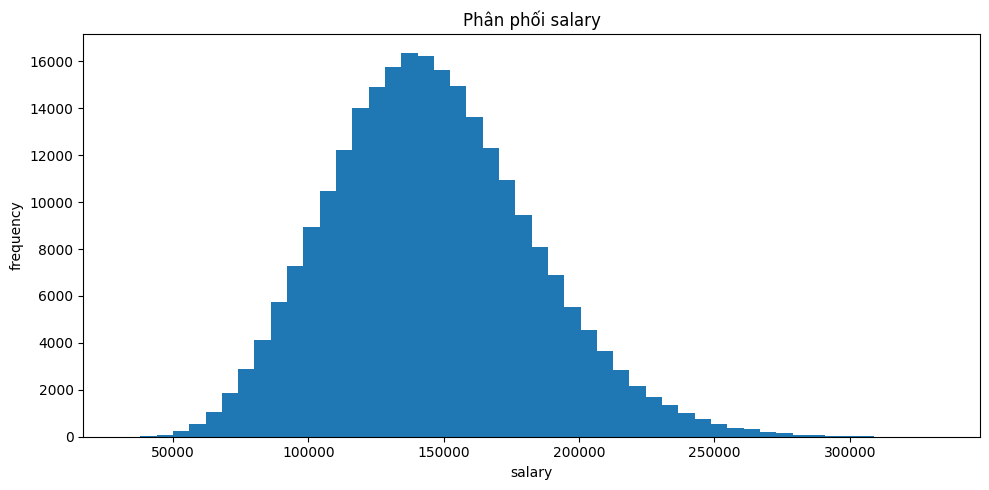

Đã lưu biểu đồ: eda_salary_outputs\01_salary_distribution_histogram.png


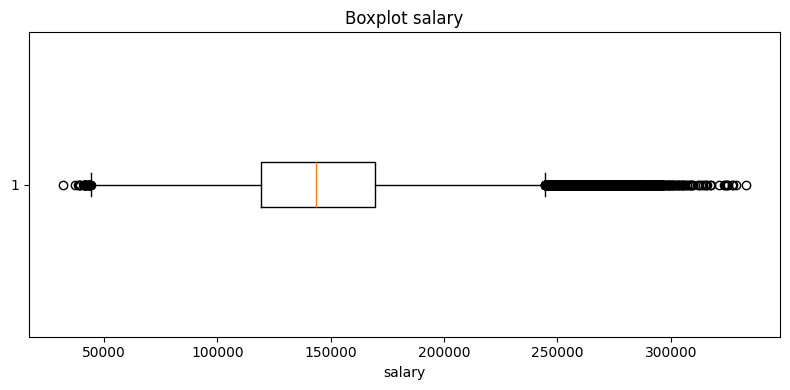

Đã lưu biểu đồ: eda_salary_outputs\02_salary_boxplot.png


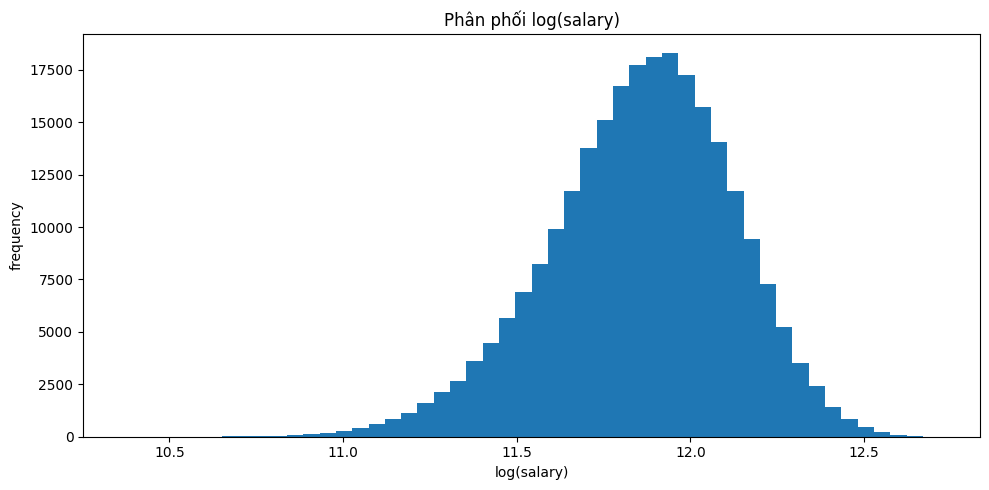

Đã lưu biểu đồ: eda_salary_outputs\03_log_salary_distribution.png
Đã tạo biến log_salary.


In [9]:
# ============================================================
# CELL 8 - SALARY DISTRIBUTION
# ============================================================

salary = df[TARGET].dropna()

plt.figure(figsize=FIGSIZE)
plt.hist(salary, bins=50)
plt.title("Phân phối salary")
plt.xlabel("salary")
plt.ylabel("frequency")
save_plot("01_salary_distribution_histogram")

plt.figure(figsize=(8, 4))
plt.boxplot(salary, vert=False)
plt.title("Boxplot salary")
plt.xlabel("salary")
save_plot("02_salary_boxplot")

# Log salary chỉ hợp lệ nếu salary > 0
if (df[TARGET] > 0).all():
    df["log_salary"] = np.log(df[TARGET])

    plt.figure(figsize=FIGSIZE)
    plt.hist(df["log_salary"].dropna(), bins=50)
    plt.title("Phân phối log(salary)")
    plt.xlabel("log(salary)")
    plt.ylabel("frequency")
    save_plot("03_log_salary_distribution")

    print("Đã tạo biến log_salary.")
else:
    print("Không tạo log_salary vì tồn tại salary <= 0.")

## Cell 9. Quan hệ giữa biến số và lương

Với biến định lượng, notebook tính tương quan Pearson bằng công thức và vẽ scatter. Để biểu đồ nhẹ, scatter chỉ lấy mẫu tối đa `SCATTER_SAMPLE` quan sát.

,feature,pearson_corr_with_salary,abs_corr
0,experience_years,0.437627,0.437627
1,skills_count,0.127300,0.127300
2,certifications,0.073819,0.073819


Đã lưu bảng: eda_salary_outputs\04_numeric_salary_correlation.csv


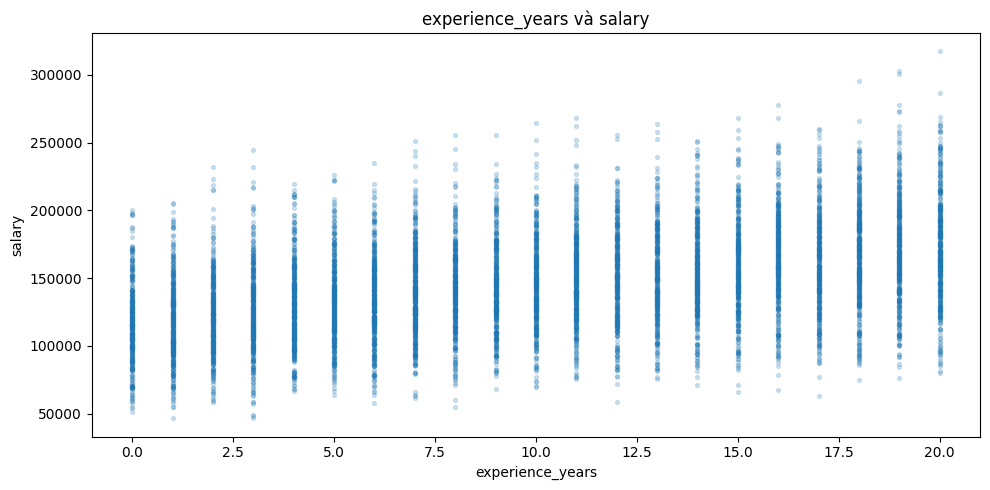

Đã lưu biểu đồ: eda_salary_outputs\04_scatter_experience_years_salary.png


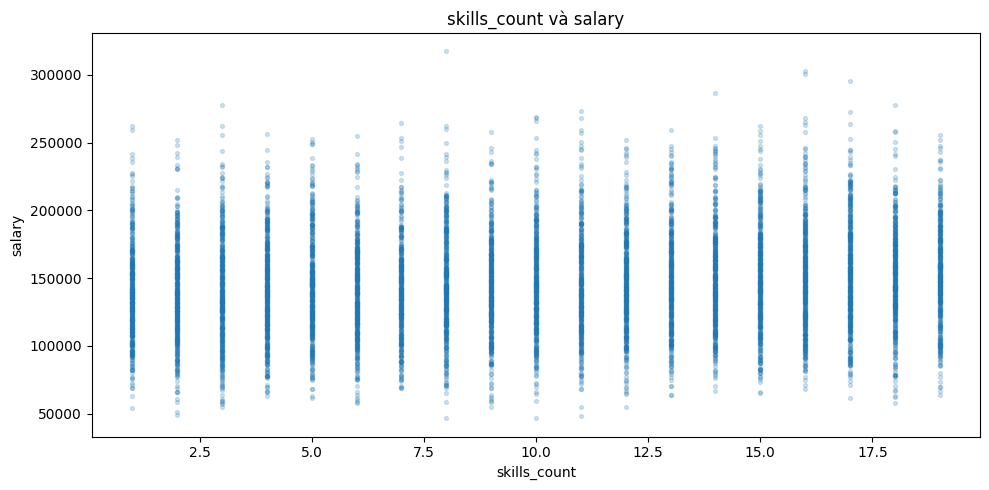

Đã lưu biểu đồ: eda_salary_outputs\04_scatter_skills_count_salary.png


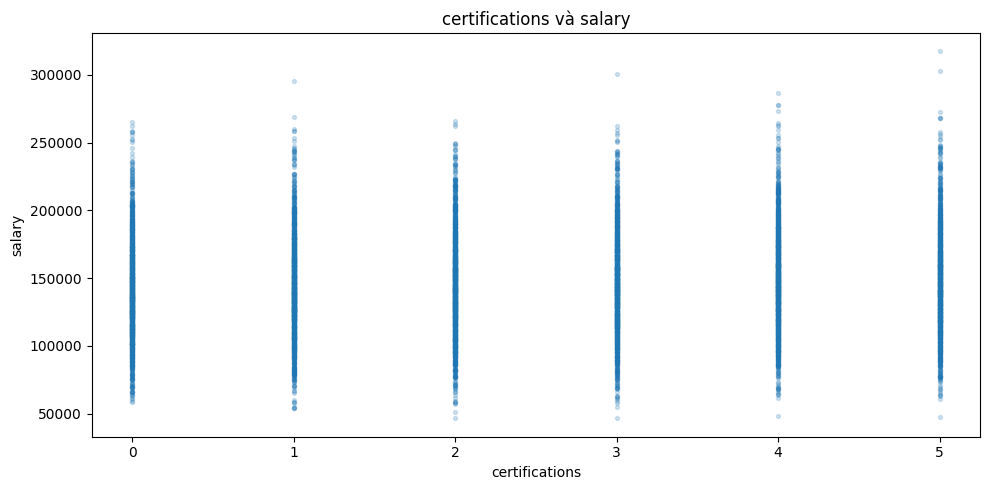

Đã lưu biểu đồ: eda_salary_outputs\04_scatter_certifications_salary.png


,experience_years_bin,count,mean,median,std,min,max
0,"(-0.001, 2.0]",35765,121460.880749,119869.0,30170.130516,31867,252252
1,"(2.0, 4.0]",23891,128311.621573,126498.0,31141.549142,39285,267543
2,"(4.0, 6.0]",23722,133342.642568,131695.5,31608.830412,41404,277135
3,"(6.0, 8.0]",23803,139103.909591,137245.0,32643.547721,50822,292052
4,"(8.0, 10.0]",23633,144262.876063,142488.0,33446.593061,50879,282476
5,"(10.0, 12.0]",23691,149467.103921,147597.0,34095.767708,54280,301995
6,"(12.0, 14.0]",23865,155270.686947,153591.0,34825.287133,54435,312367
7,"(14.0, 16.0]",23960,160626.058556,158952.0,35738.356406,59838,309091
8,"(16.0, 18.0]",23837,165875.848051,164038.0,36212.540351,61211,327217
9,"(18.0, 20.0]",23833,171494.425670,169835.0,37721.043546,64532,333046


Đã lưu bảng: eda_salary_outputs\05_salary_by_experience_years_bins.csv


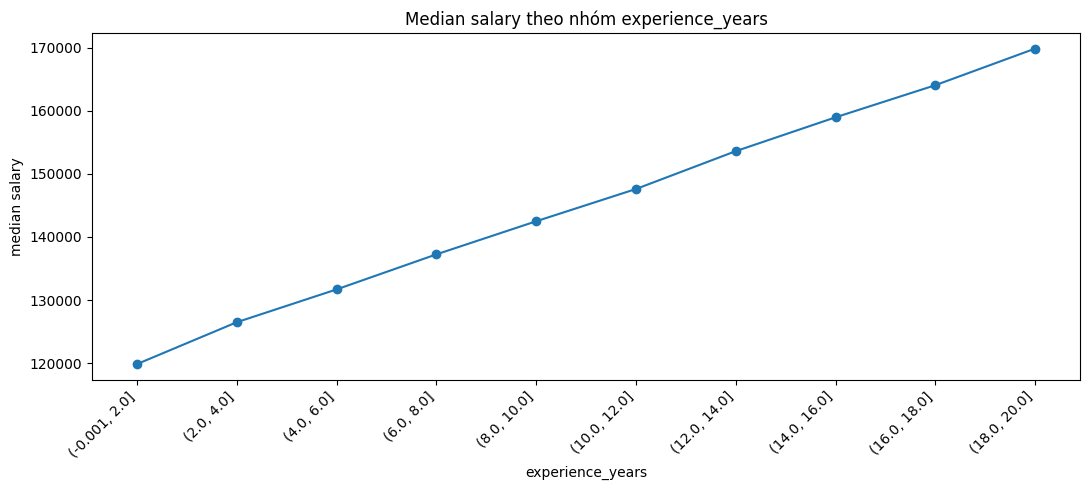

Đã lưu biểu đồ: eda_salary_outputs\05_median_salary_by_experience_years_bins.png


,skills_count_bin,count,mean,median,std,min,max
0,"(0.999, 2.0]",26342,138317.385316,135854.5,36079.428539,31867,314829
1,"(2.0, 4.0]",26288,140159.906497,138151.5,36323.619645,38779,324583
2,"(4.0, 6.0]",26380,141783.603146,139437.0,36523.659119,39285,305515
3,"(6.0, 8.0]",26318,143381.771221,141226.5,36913.025039,37213,317497
4,"(8.0, 10.0]",26448,145065.224781,142909.0,37127.470498,41276,328616
5,"(10.0, 12.0]",26046,147299.546149,144959.0,37382.171723,43284,333046
6,"(12.0, 14.0]",26399,148826.010834,146691.0,37541.513536,43231,314060
7,"(14.0, 16.0]",26277,150620.361038,148683.0,37797.264840,47684,327217
8,"(16.0, 18.0]",26366,152311.729804,150092.5,37914.934599,46650,327025
9,"(18.0, 19.0]",13136,153156.047503,150933.5,37710.404374,52590,315928


Đã lưu bảng: eda_salary_outputs\05_salary_by_skills_count_bins.csv


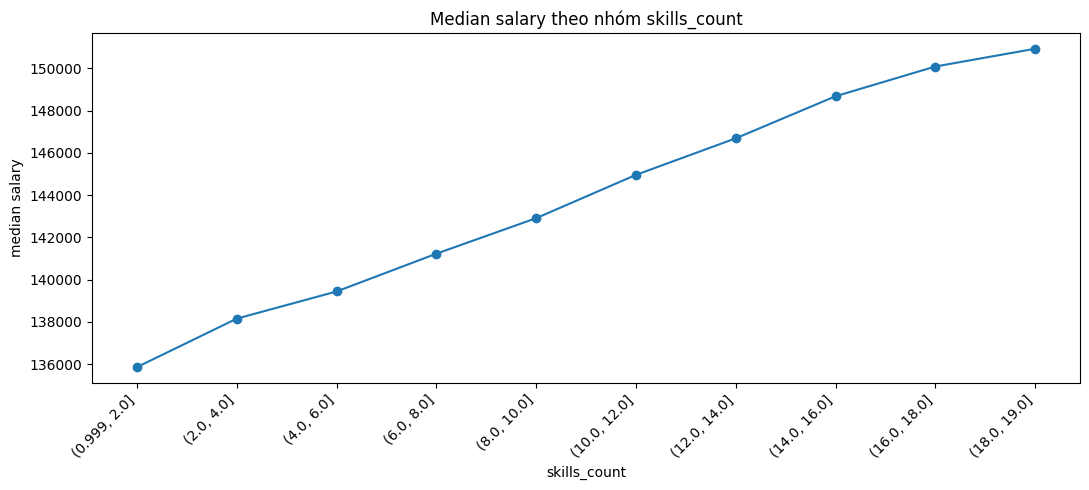

Đã lưu biểu đồ: eda_salary_outputs\05_median_salary_by_skills_count_bins.png


,certifications_bin,count,mean,median,std,min,max
0,"(-0.001, 1.0]",83589,142455.193937,140298.0,36824.450030,31867,325052
1,"(1.0, 2.0]",41744,144868.706976,142481.5,37135.293720,39141,314829
2,"(2.0, 3.0]",41974,146884.292491,144486.5,37689.215576,39285,321127
3,"(3.0, 4.0]",41467,148103.275327,145914.0,37624.483291,38779,333046
4,"(4.0, 5.0]",41226,149607.379081,147291.5,37755.759203,43890,328616


Đã lưu bảng: eda_salary_outputs\05_salary_by_certifications_bins.csv


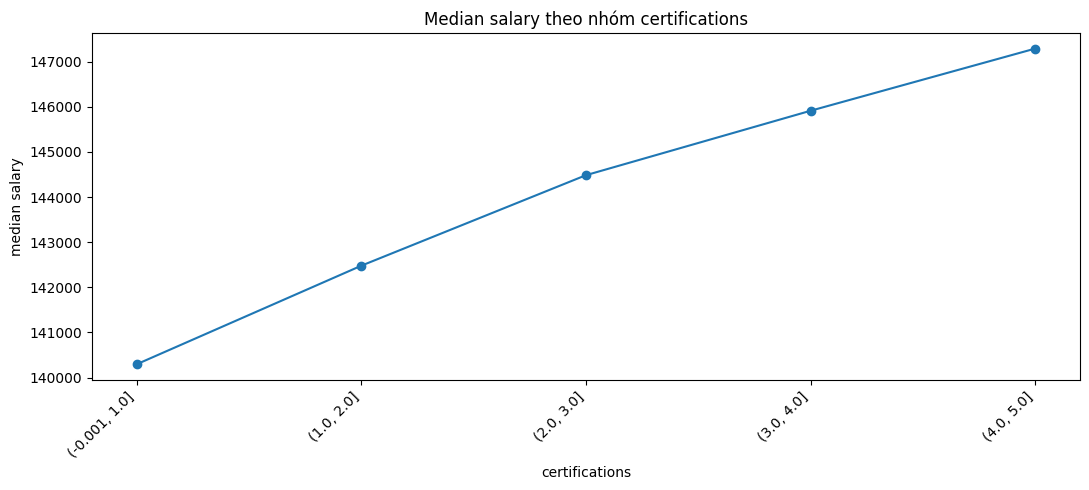

Đã lưu biểu đồ: eda_salary_outputs\05_median_salary_by_certifications_bins.png


In [10]:
# ============================================================
# CELL 9 - NUMERIC FEATURES VS SALARY
# ============================================================

numeric_relation_rows = []

for col in numeric_features:
    corr = pearson_corr_by_formula(df[col], df[TARGET])

    numeric_relation_rows.append({
        "feature": col,
        "pearson_corr_with_salary": corr,
        "abs_corr": abs(corr)
    })

numeric_relation = (
    pd.DataFrame(numeric_relation_rows)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

display(numeric_relation)
save_table(numeric_relation, "04_numeric_salary_correlation")

# Lấy mẫu để vẽ scatter
plot_df = df.sample(n=min(SCATTER_SAMPLE, len(df)), random_state=42)

for col in numeric_features:
    plt.figure(figsize=FIGSIZE)
    plt.scatter(plot_df[col], plot_df[TARGET], alpha=0.20, s=8)
    plt.title(f"{col} và salary")
    plt.xlabel(col)
    plt.ylabel("salary")
    save_plot(f"04_scatter_{col}_salary")

# Salary theo nhóm phân vị của biến số
for col in numeric_features:
    temp = df[[col, TARGET]].dropna().copy()

    temp[f"{col}_bin"] = pd.qcut(
        temp[col],
        q=N_BINS_NUMERIC,
        duplicates="drop"
    )

    bin_summary = (
        temp.groupby(f"{col}_bin", observed=True)[TARGET]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )

    display(bin_summary)
    save_table(bin_summary, f"05_salary_by_{col}_bins")

    plt.figure(figsize=(11, 5))
    x_labels = bin_summary[f"{col}_bin"].astype(str)
    plt.plot(range(len(bin_summary)), bin_summary["median"], marker="o")
    plt.xticks(range(len(bin_summary)), x_labels, rotation=45, ha="right")
    plt.title(f"Median salary theo nhóm {col}")
    plt.xlabel(col)
    plt.ylabel("median salary")
    save_plot(f"05_median_salary_by_{col}_bins")

## Cell 10. Quan hệ giữa biến phân loại và lương

Với biến phân loại, notebook tính `eta_squared` và tạo bảng lương theo từng nhóm. Đây là phần rất quan trọng cho DSS vì giúp xác định biến nào nên dùng để phân nhóm benchmark.

,feature,eta_squared
0,location,0.323531
1,company_size,0.164964
2,job_title,0.161269
3,education_level,0.095840
4,remote_work,0.004497
5,industry,0.000027


Đã lưu bảng: eda_salary_outputs\06_categorical_effect_eta_squared.csv


,job_title,count,mean,median,std,q25,q75,min,max
0,AI Engineer,20945,173498.480640,171674.0,38093.174492,147656.00,197491.00,66371,333046
9,Machine Learning Engineer,20677,163022.504570,160933.0,36890.759788,138044.00,186460.00,59925,317377
10,Product Manager,20950,157594.932029,155655.5,35754.582620,133200.75,180141.75,59796,301294
3,Cloud Engineer,20686,152102.535290,150005.0,35120.102332,127965.00,174456.00,45030,292855
7,DevOps Engineer,20889,149959.266791,148021.0,34455.584420,125860.00,172099.00,54985,304968
4,Cybersecurity Analyst,20959,148697.695548,146737.0,34525.312743,124981.00,170253.50,54224,303178
6,Data Scientist,20890,147258.214409,145231.5,34227.020507,123540.75,168962.25,51349,288049
11,Software Engineer,20876,141739.521460,139432.5,33621.958420,117949.75,163190.00,51313,284442
1,Backend Developer,21125,139202.768663,136678.0,33198.872580,115936.00,160549.00,46304,290512
8,Frontend Developer,20633,132653.842485,130619.0,32358.068413,109773.00,153279.00,44964,277053


Đã lưu bảng: eda_salary_outputs\07_salary_by_job_title.csv


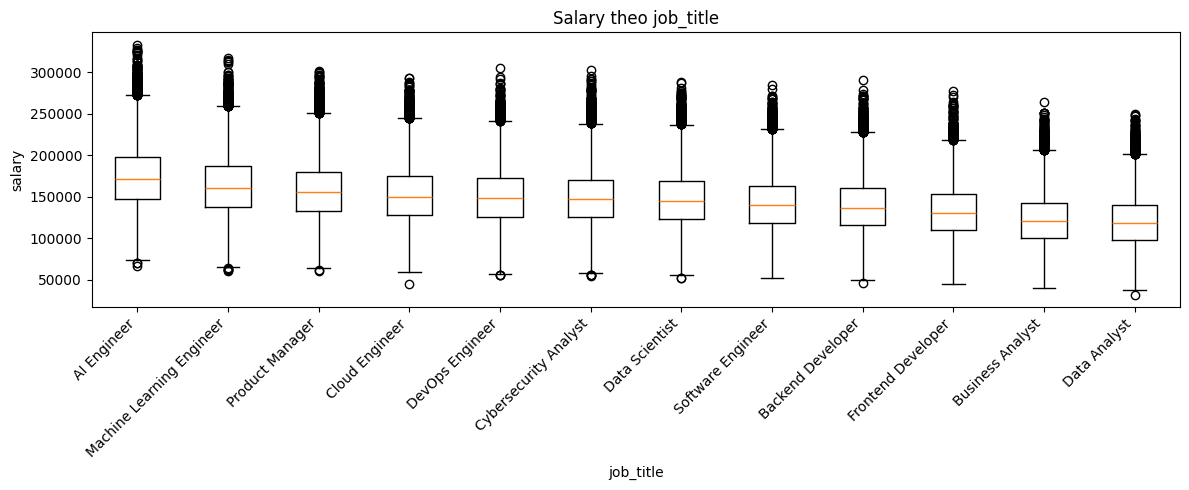

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_job_title.png


,education_level,count,mean,median,std,q25,q75,min,max
4,PhD,49857,163976.005295,162005.0,38149.434745,137637.00,188370.00,50823,333046
3,Master,50352,153305.307833,151396.5,36529.815853,127729.75,176683.75,50201,315928
0,Bachelor,49950,142410.531291,140631.5,35105.903931,117857.75,164885.75,41276,298070
1,Diploma,49776,137158.574976,135283.0,34275.205234,113138.75,158873.00,41812,293306
2,High School,50065,131715.336243,129663.0,33601.793888,107881.00,153269.00,31867,287961


Đã lưu bảng: eda_salary_outputs\07_salary_by_education_level.csv


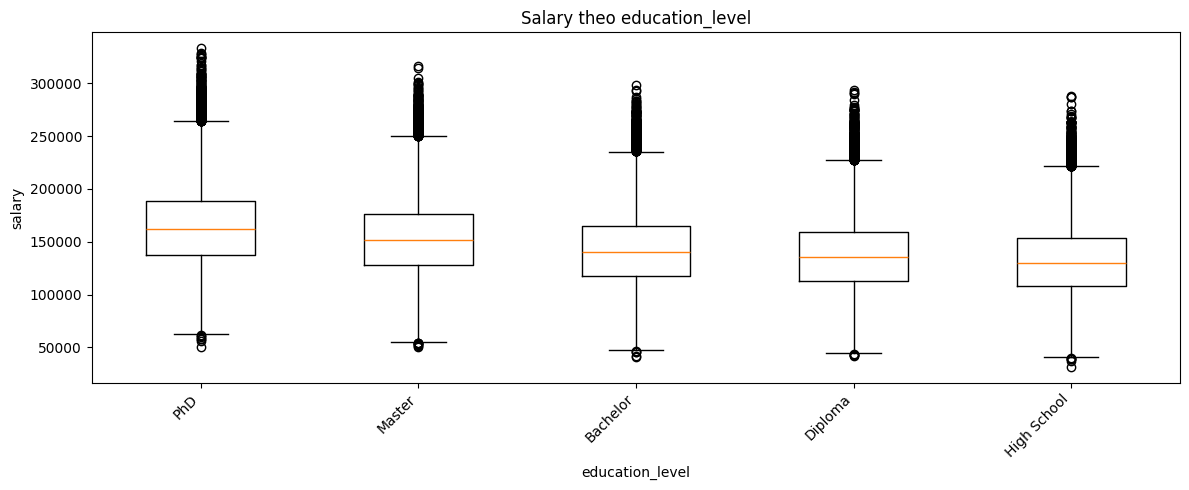

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_education_level.png


,industry,count,mean,median,std,q25,q75,min,max
4,Healthcare,24898,145759.995702,143998.5,37374.489476,119475.50,169439.50,38779,317377
2,Finance,25393,145801.639468,143858.0,37389.248072,119411.00,169686.00,39285,314829
1,Education,24889,145993.564547,143627.0,37362.763835,119524.00,169595.00,42161,317497
6,Media,25034,145891.271071,143591.5,37524.342983,119687.00,169334.25,41716,309091
9,Telecom,24859,145876.511967,143380.0,37607.922256,119414.50,169588.50,42275,324583
8,Technology,24903,145863.808377,143359.0,37319.790194,119574.00,170003.00,41108,327217
7,Retail,24841,145399.699408,143234.0,37311.821280,119076.00,169198.00,31867,321127
0,Consulting,25258,145451.638293,143202.0,37324.243935,119304.25,169087.00,39141,333046
3,Government,24901,145613.869242,143176.0,37496.213976,119063.00,169426.00,41193,328616
5,Manufacturing,25024,145530.603301,143119.5,37370.378549,118983.25,169486.00,47254,327025


Đã lưu bảng: eda_salary_outputs\07_salary_by_industry.csv


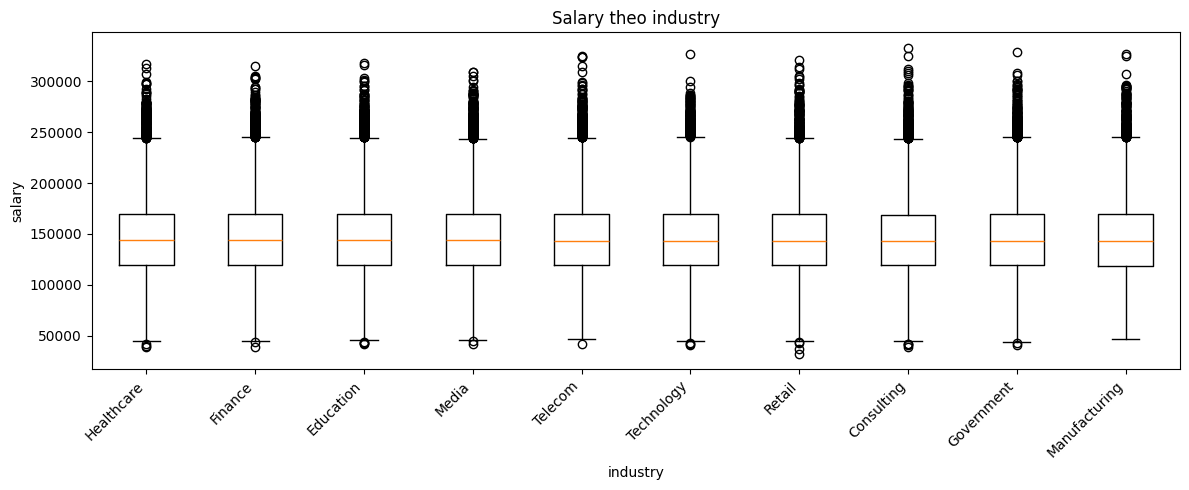

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_industry.png


,company_size,count,mean,median,std,q25,q75,min,max
0,Enterprise,49875,169616.398957,168958.0,39594.383396,141895.5,195652.00,52754,333046
1,Large,50254,155711.112489,154981.0,36364.880007,130438.0,179675.75,45599,306036
2,Medium,50027,141537.535991,140861.0,32942.663686,118503.5,163342.00,41108,274496
3,Small,50235,134356.864298,134001.0,31247.189000,112662.0,155027.50,39285,270596
4,Startup,49609,127289.011974,126660.0,29831.337143,106613.0,146863.00,31867,245503


Đã lưu bảng: eda_salary_outputs\07_salary_by_company_size.csv


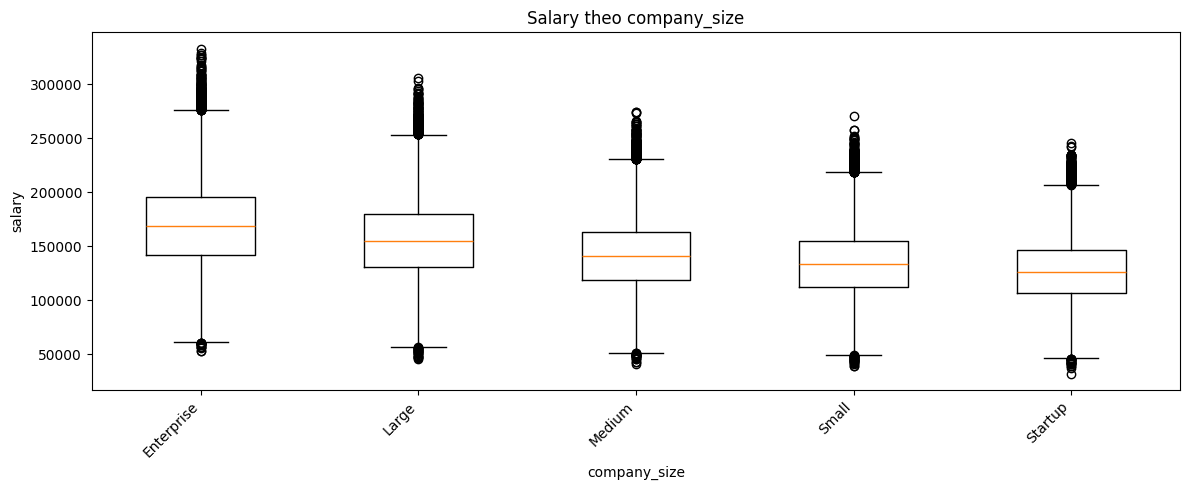

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_company_size.png


,location,count,mean,median,std,q25,q75,min,max
9,USA,24931,181716.303919,179647.0,37750.674479,154841.50,206069.50,73777,333046
1,Canada,25165,167391.273396,165474.0,34851.556151,142659.00,190110.00,66389,301628
8,UK,24927,160075.143018,158191.0,33447.423188,136177.50,181744.50,60519,303039
2,Germany,24763,153376.211000,151538.0,32026.863678,130754.00,174423.50,54720,286402
7,Sweden,25100,139440.637291,138033.0,29070.535100,118730.00,158346.50,58303,253232
5,Remote,25065,139442.525155,137836.0,28965.917916,118931.00,158410.00,48124,255829
0,Australia,25258,139362.150804,137753.5,29286.031074,118977.75,158352.75,50747,247687
6,Singapore,25035,139340.696625,137699.0,29084.856226,118626.00,158334.00,52787,258256
4,Netherlands,24861,139294.813644,137356.0,29317.421435,118479.00,158621.00,56142,251452
3,India,24895,97690.402249,96501.0,20857.457121,83018.50,111158.50,31867,193268


Đã lưu bảng: eda_salary_outputs\07_salary_by_location.csv


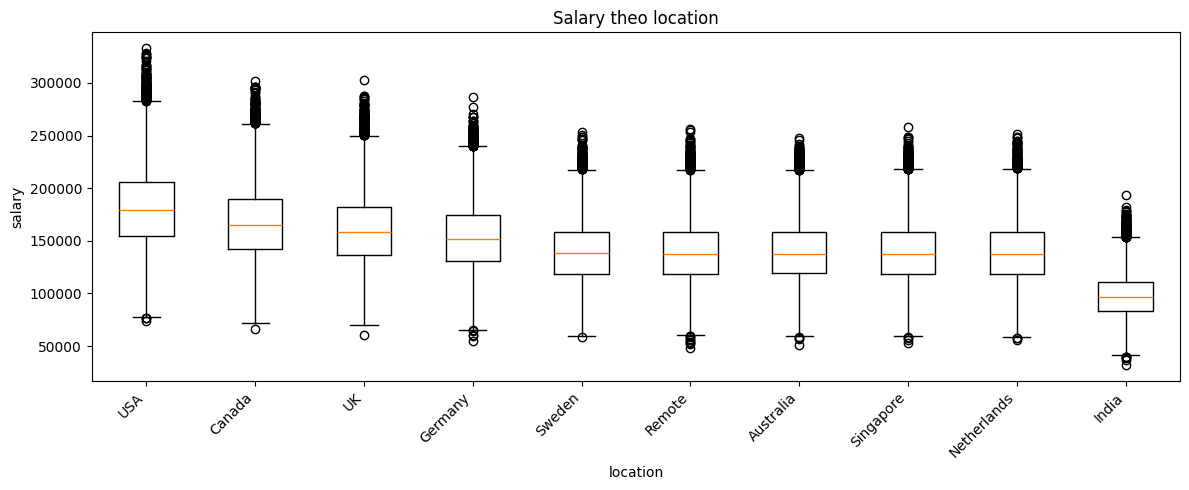

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_location.png


,remote_work,count,mean,median,std,q25,q75,min,max
2,Yes,82903,149279.589822,147153.0,37656.806813,122870.5,173202.5,39141,333046
0,Hybrid,83476,143969.899839,141672.0,37071.239937,117738.0,167503.5,38779,327217
1,No,83621,143932.300941,141630.0,37243.626648,117652.0,167588.0,31867,328616


Đã lưu bảng: eda_salary_outputs\07_salary_by_remote_work.csv


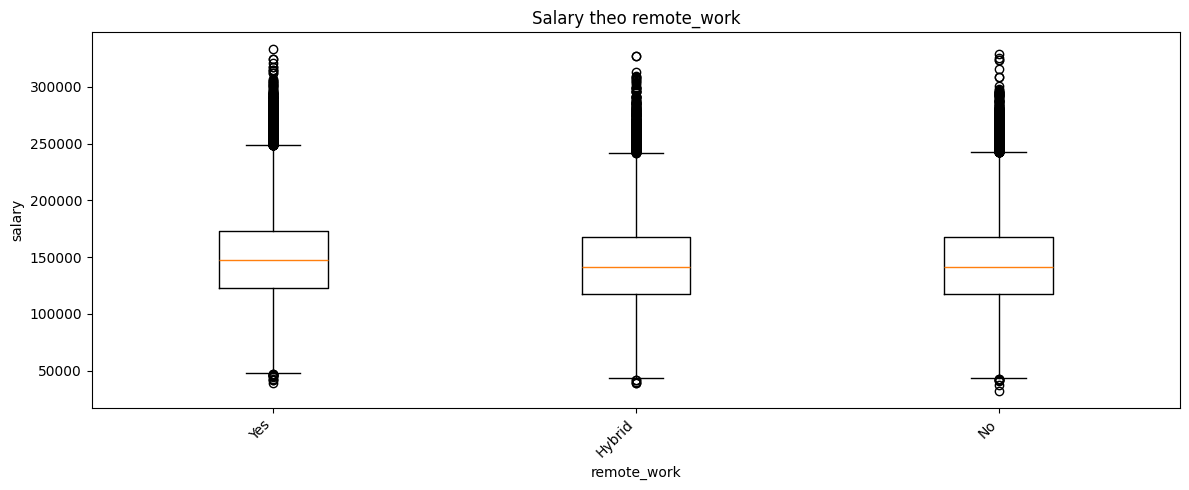

Đã lưu biểu đồ: eda_salary_outputs\06_salary_boxplot_by_remote_work.png


In [11]:
# ============================================================
# CELL 10 - CATEGORICAL FEATURES VS SALARY
# ============================================================

cat_effect_rows = []

for col in categorical_features:
    eta2 = eta_squared(df, col, TARGET)

    cat_effect_rows.append({
        "feature": col,
        "eta_squared": eta2
    })

cat_effect = (
    pd.DataFrame(cat_effect_rows)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

display(cat_effect)
save_table(cat_effect, "06_categorical_effect_eta_squared")

for col in categorical_features:
    group_summary = (
        df.groupby(col, dropna=False)[TARGET]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            min="min",
            max="max"
        )
        .reset_index()
        .sort_values("median", ascending=False)
    )

    display(group_summary)
    save_table(group_summary, f"07_salary_by_{col}")

    # Chỉ vẽ TOP_N_CATEGORY nhóm có trung vị salary cao nhất
    top_groups = group_summary.head(TOP_N_CATEGORY)[col].astype(str).tolist()
    plot_data = df[df[col].astype(str).isin(top_groups)]

    labels = []
    data_to_plot = []

    for group in top_groups:
        values = plot_data.loc[plot_data[col].astype(str) == group, TARGET].dropna()
        labels.append(group)
        data_to_plot.append(values)

    plt.figure(figsize=(12, 5))
    plt.boxplot(data_to_plot, labels=labels, vert=True)
    plt.title(f"Salary theo {col}")
    plt.xlabel(col)
    plt.ylabel("salary")
    plt.xticks(rotation=45, ha="right")
    save_plot(f"06_salary_boxplot_by_{col}")

## Cell 11. Ma trận tương quan biến số

Ma trận này dùng để xem các biến định lượng có quan hệ tuyến tính với nhau và với `salary` như thế nào.

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


Đã lưu bảng: eda_salary_outputs\08_numeric_correlation_matrix.csv


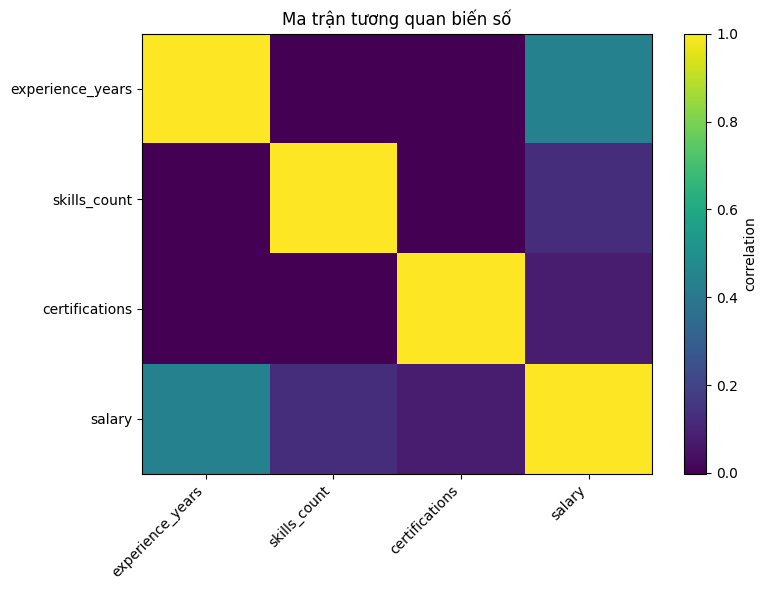

Đã lưu biểu đồ: eda_salary_outputs\07_numeric_correlation_matrix.png


In [12]:
# ============================================================
# CELL 11 - NUMERIC CORRELATION MATRIX
# ============================================================

numeric_cols_for_corr = numeric_features + [TARGET]
corr_matrix = df[numeric_cols_for_corr].corr()

display(corr_matrix)
save_table(
    corr_matrix.reset_index().rename(columns={"index": "variable"}),
    "08_numeric_correlation_matrix"
)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Ma trận tương quan biến số")
save_plot("07_numeric_correlation_matrix")

## Cell 12. Phát hiện ngoại lai lương

Ngoại lai được phát hiện bằng quy tắc IQR. Với dữ liệu lương, không nên xóa ngoại lai máy móc vì mức lương cao có thể hợp lệ nếu thuộc nhóm nghề, kinh nghiệm, địa điểm hoặc công ty đặc biệt.

In [13]:
# ============================================================
# CELL 12 - OUTLIER ANALYSIS FOR SALARY
# ============================================================

outlier_flag, lower_bound, upper_bound = iqr_outlier_flag(df[TARGET])
df["salary_outlier_iqr"] = outlier_flag

outlier_summary = pd.DataFrame({
    "rule": ["IQR"],
    "lower_bound": [lower_bound],
    "upper_bound": [upper_bound],
    "n_outliers": [outlier_flag.sum()],
    "outlier_rate": [outlier_flag.mean()]
})

display(outlier_summary)
save_table(outlier_summary, "09_salary_outlier_summary")

# Ngoại lai theo job_title nếu tồn tại biến này
if "job_title" in df.columns:
    rows = []

    for job, group in df.groupby("job_title"):
        flag, lb, ub = iqr_outlier_flag(group[TARGET])

        rows.append({
            "job_title": job,
            "count": len(group),
            "lower_bound": lb,
            "upper_bound": ub,
            "n_outliers": flag.sum(),
            "outlier_rate": flag.mean()
        })

    outlier_by_job = (
        pd.DataFrame(rows)
        .sort_values("outlier_rate", ascending=False)
        .reset_index(drop=True)
    )

    display(outlier_by_job)
    save_table(outlier_by_job, "10_salary_outlier_by_job_title")

,rule,lower_bound,upper_bound,n_outliers,outlier_rate
0,IQR,44157.0,244693.0,2336,0.009344


Đã lưu bảng: eda_salary_outputs\09_salary_outlier_summary.csv


,job_title,count,lower_bound,upper_bound,n_outliers,outlier_rate
0,Cybersecurity Analyst,20959,57072.250,238162.250,229,0.010926
1,AI Engineer,20945,72903.500,272243.500,217,0.010360
2,Product Manager,20950,62789.250,250553.250,210,0.010024
3,Machine Learning Engineer,20677,65420.000,259084.000,203,0.009818
4,Cloud Engineer,20686,58228.500,244192.500,197,0.009523
5,Data Analyst,20722,35976.250,201246.250,197,0.009507
6,Backend Developer,21125,49016.500,227468.500,200,0.009467
7,Software Engineer,20876,50089.375,231050.375,192,0.009197
8,Data Scientist,20890,55408.500,237094.500,190,0.009095
9,Business Analyst,20648,36724.500,206196.500,180,0.008718


Đã lưu bảng: eda_salary_outputs\10_salary_outlier_by_job_title.csv


## Cell 13. Bảng benchmark lương phục vụ DSS

Bảng benchmark là đầu vào trực tiếp cho hệ hỗ trợ quyết định. Một cách dùng tự nhiên:

- `q25`: mức lương thấp hợp lý.
- `median`: mức lương khuyến nghị chính.
- `q75`: mức lương cao hợp lý để đàm phán.
- `count`: độ tin cậy của nhóm tham chiếu.

In [14]:
# ============================================================
# CELL 13 - DSS SALARY BENCHMARK TABLE
# ============================================================

def make_salary_benchmark(data, group_cols, target, min_group_size=100):
    """
    Tạo bảng benchmark lương theo nhóm hồ sơ.

    Input:
        data: DataFrame
        group_cols: danh sách biến dùng để phân nhóm
        target: biến lương
        min_group_size: cỡ mẫu tối thiểu

    Output:
        DataFrame gồm count, mean, median, q25, q75, min, max.
    """
    benchmark = (
        data.groupby(group_cols, dropna=False, observed=True)[target]
        .agg(
            count="count",
            mean="mean",
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            min="min",
            max="max"
        )
        .reset_index()
    )

    benchmark = benchmark[benchmark["count"] >= min_group_size].copy()
    benchmark = benchmark.sort_values("median", ascending=False).reset_index(drop=True)

    return benchmark


# Benchmark cấp 1: theo các biến hồ sơ quan trọng
benchmark_cols_1 = [
    "job_title",
    "education_level",
    "remote_work",
    "company_size"
]
benchmark_cols_1 = [c for c in benchmark_cols_1 if c in df.columns]

salary_benchmark_1 = make_salary_benchmark(
    data=df,
    group_cols=benchmark_cols_1,
    target=TARGET,
    min_group_size=MIN_GROUP_SIZE
)

display(salary_benchmark_1.head(30))
save_table(salary_benchmark_1, "11_dss_salary_benchmark_main")

# Benchmark cấp 2: thêm nhóm kinh nghiệm
if "experience_years" in df.columns:
    df["experience_group"] = pd.cut(
        df["experience_years"],
        bins=[-1, 2, 5, 10, 15, 20, 100],
        labels=[
            "0-2 years",
            "3-5 years",
            "6-10 years",
            "11-15 years",
            "16-20 years",
            "20+ years"
        ]
    )

    benchmark_cols_2 = [
        "job_title",
        "experience_group",
        "education_level",
        "remote_work"
    ]
    benchmark_cols_2 = [c for c in benchmark_cols_2 if c in df.columns]

    salary_benchmark_2 = make_salary_benchmark(
        data=df,
        group_cols=benchmark_cols_2,
        target=TARGET,
        min_group_size=MIN_GROUP_SIZE
    )

    display(salary_benchmark_2.head(30))
    save_table(salary_benchmark_2, "12_dss_salary_benchmark_by_experience")

,job_title,education_level,remote_work,company_size,count,mean,median,q25,q75,min,max
0,AI Engineer,PhD,Hybrid,Enterprise,304,222149.687500,224542.5,198716.50,243928.00,120312,327217
1,AI Engineer,PhD,Yes,Enterprise,282,222972.482270,221818.0,195362.50,251257.50,129068,333046
2,AI Engineer,PhD,No,Enterprise,247,220632.688259,219814.0,199178.00,244122.50,121663,328616
3,Machine Learning Engineer,PhD,Yes,Enterprise,288,216077.343750,218551.5,189414.75,238548.75,122966,317377
4,AI Engineer,Master,Yes,Enterprise,259,212984.907336,216666.0,185371.50,238950.50,120420,314060
5,Product Manager,PhD,Yes,Enterprise,292,211791.708904,212919.0,188619.75,232306.50,115625,301294
6,Machine Learning Engineer,PhD,No,Enterprise,310,210251.425806,212480.5,189670.75,235617.25,111190,300503
7,AI Engineer,PhD,Yes,Large,281,210701.868327,210497.0,186992.00,232070.00,127614,306036
8,Machine Learning Engineer,PhD,Hybrid,Enterprise,277,207774.830325,209155.0,184923.00,229568.00,117506,313157
9,AI Engineer,Master,Hybrid,Enterprise,294,207252.986395,207858.5,183051.75,231260.75,117675,299036


Đã lưu bảng: eda_salary_outputs\11_dss_salary_benchmark_main.csv


,job_title,experience_group,education_level,remote_work,count,mean,median,q25,q75,min,max
0,AI Engineer,16-20 years,PhD,Yes,345,217776.179710,216090.0,190509.00,244621.00,118877,333046
1,AI Engineer,16-20 years,PhD,Hybrid,353,213936.331445,214509.0,189711.00,235038.00,112927,327217
2,AI Engineer,16-20 years,PhD,No,301,210462.189369,208659.0,185822.00,232597.00,114312,328616
3,AI Engineer,16-20 years,Master,Yes,293,207201.870307,208444.0,184042.00,229622.00,113273,314060
4,Machine Learning Engineer,16-20 years,PhD,Hybrid,322,202640.413043,203535.5,179595.00,227193.00,107470,313157
5,Machine Learning Engineer,16-20 years,PhD,Yes,323,206287.891641,202284.0,179627.00,232803.50,107974,317377
6,Machine Learning Engineer,16-20 years,PhD,No,356,203810.587079,201484.0,178553.00,229338.50,111489,300503
7,Product Manager,16-20 years,PhD,Yes,353,200096.620397,198871.0,174977.00,224266.00,110957,301294
8,AI Engineer,11-15 years,PhD,Hybrid,340,199368.520588,198400.5,175549.00,222475.50,106727,307906
9,AI Engineer,11-15 years,PhD,No,299,197335.441472,197488.0,172266.50,221187.50,106369,308894


Đã lưu bảng: eda_salary_outputs\12_dss_salary_benchmark_by_experience.csv


## Cell 14. Hàm tư vấn lương thử nghiệm cho DSS

Đây chưa phải mô hình machine learning. Đây là mô-đun DSS baseline dựa trên thống kê mô tả. Nó có thể dùng để giải thích logic hệ thống trước khi xây dựng mô hình hồi quy.

In [15]:
# ============================================================
# CELL 14 - SIMPLE DSS SALARY ADVISOR
# ============================================================

def recommend_salary_range(
    data,
    target,
    job_title=None,
    experience_years=None,
    education_level=None,
    remote_work=None,
    company_size=None,
    industry=None,
    location=None,
    min_group_size=30
):
    """
    Tư vấn khoảng lương dựa trên nhóm hồ sơ gần nhất.

    Nguyên tắc:
        1. Lọc theo kinh nghiệm quanh mức nhập vào.
        2. Lọc dần theo thông tin người dùng cung cấp.
        3. Nếu lọc làm nhóm quá nhỏ thì bỏ điều kiện đó để tránh benchmark thiếu tin cậy.
        4. Trả về q25, median, q75 làm khoảng gợi ý.

    Diễn giải:
        q25    : mức thấp hợp lý
        median : mức khuyến nghị chính
        q75    : mức cao hợp lý để đàm phán
    """

    temp = data.copy()
    used_conditions = []

    # Lọc kinh nghiệm trong biên +-2 năm
    if experience_years is not None and "experience_years" in temp.columns:
        candidate = temp[
            (temp["experience_years"] >= experience_years - 2) &
            (temp["experience_years"] <= experience_years + 2)
        ]

        if len(candidate) >= min_group_size:
            temp = candidate
            used_conditions.append(("experience_years_range", f"{experience_years - 2} to {experience_years + 2}"))

    # Các điều kiện phân loại
    conditions = [
        ("job_title", job_title),
        ("education_level", education_level),
        ("remote_work", remote_work),
        ("company_size", company_size),
        ("industry", industry),
        ("location", location),
    ]

    for col, value in conditions:
        if value is None:
            continue

        if col not in temp.columns:
            continue

        candidate = temp[temp[col] == value]

        if len(candidate) >= min_group_size:
            temp = candidate
            used_conditions.append((col, value))

    if len(temp) == 0:
        return {
            "status": "failed",
            "message": "Không tìm được nhóm tham chiếu phù hợp.",
            "n_reference_cases": 0
        }

    result = {
        "status": "success",
        "n_reference_cases": int(len(temp)),
        "used_conditions": used_conditions,
        "recommended_low_q25": float(temp[target].quantile(0.25)),
        "recommended_mid_median": float(temp[target].median()),
        "recommended_high_q75": float(temp[target].quantile(0.75)),
        "mean_salary": float(temp[target].mean()),
        "min_salary": float(temp[target].min()),
        "max_salary": float(temp[target].max())
    }

    return result


# Ví dụ minh họa
example_recommendation = recommend_salary_range(
    data=df,
    target=TARGET,
    job_title="Data Analyst",
    experience_years=5,
    education_level="Bachelor",
    remote_work="Hybrid",
    company_size="Medium"
)

example_recommendation

{'status': 'success',
 'n_reference_cases': 61,
 'used_conditions': [('experience_years_range', '3 to 7'),
  ('job_title', 'Data Analyst'),
  ('education_level', 'Bachelor'),
  ('remote_work', 'Hybrid'),
  ('company_size', 'Medium')],
 'recommended_low_q25': 92958.0,
 'recommended_mid_median': 100669.0,
 'recommended_high_q75': 105859.0,
 'mean_salary': 98560.90163934426,
 'min_salary': 60341.0,
 'max_salary': 135509.0}

## Cell 15. Tạo kết luận EDA tự động

Bảng này có thể dùng trực tiếp để viết phần nhận xét trong báo cáo.

In [16]:
# ============================================================
# CELL 15 - AUTOMATIC EDA CONCLUSION FOR REPORT
# ============================================================

conclusion_rows = []

global_salary_mean = df[TARGET].mean()
global_salary_median = df[TARGET].median()
global_salary_q25 = df[TARGET].quantile(0.25)
global_salary_q75 = df[TARGET].quantile(0.75)

conclusion_rows.append({
    "aspect": "Dataset size",
    "finding": f"Dữ liệu có {df.shape[0]:,} quan sát và {df.shape[1]} biến.",
    "dss_implication": "Kích thước dữ liệu đủ lớn để xây dựng mô hình dự đoán lương và bảng benchmark."
})

conclusion_rows.append({
    "aspect": "Target salary",
    "finding": (
        f"Salary có mean = {global_salary_mean:,.2f}, "
        f"median = {global_salary_median:,.2f}, "
        f"q25 = {global_salary_q25:,.2f}, "
        f"q75 = {global_salary_q75:,.2f}."
    ),
    "dss_implication": "Median và khoảng q25-q75 phù hợp để tư vấn mức lương tham chiếu."
})

if len(numeric_relation) > 0:
    top_numeric = numeric_relation.iloc[0]

    conclusion_rows.append({
        "aspect": "Strongest numeric relation",
        "finding": (
            f"Biến số liên hệ mạnh nhất với salary là {top_numeric['feature']} "
            f"với Pearson correlation = {top_numeric['pearson_corr_with_salary']:.4f}."
        ),
        "dss_implication": "Biến này nên được ưu tiên trong mô hình dự đoán và giao diện nhập liệu."
    })

if len(cat_effect) > 0:
    top_cat = cat_effect.iloc[0]

    conclusion_rows.append({
        "aspect": "Strongest categorical effect",
        "finding": (
            f"Biến phân loại phân tách salary mạnh nhất là {top_cat['feature']} "
            f"với eta_squared = {top_cat['eta_squared']:.4f}."
        ),
        "dss_implication": "Biến này nên được dùng để phân nhóm benchmark lương."
    })

if "salary_outlier_iqr" in df.columns:
    conclusion_rows.append({
        "aspect": "Salary outlier",
        "finding": (
            f"Theo quy tắc IQR, có {int(df['salary_outlier_iqr'].sum()):,} "
            f"quan sát ngoại lai, tương ứng {df['salary_outlier_iqr'].mean():.4%}."
        ),
        "dss_implication": "Không nên xóa ngoại lai máy móc; cần đánh giá theo nhóm nghề và kinh nghiệm."
    })

eda_conclusion = pd.DataFrame(conclusion_rows)

display(eda_conclusion)
save_table(eda_conclusion, "13_eda_conclusion_for_dss")

,aspect,finding,dss_implication
0,Dataset size,"Dữ liệu có 250,000 quan sát và 13 biến.",Kích thước dữ liệu đủ lớn để xây dựng mô hình ...
1,Target salary,"Salary có mean = 145,718.08, median = 143,453....",Median và khoảng q25-q75 phù hợp để tư vấn mức...
2,Strongest numeric relation,Biến số liên hệ mạnh nhất với salary là experi...,Biến này nên được ưu tiên trong mô hình dự đoá...
3,Strongest categorical effect,Biến phân loại phân tách salary mạnh nhất là l...,Biến này nên được dùng để phân nhóm benchmark ...
4,Salary outlier,"Theo quy tắc IQR, có 2,336 quan sát ngoại lai,...",Không nên xóa ngoại lai máy móc; cần đánh giá ...


Đã lưu bảng: eda_salary_outputs\13_eda_conclusion_for_dss.csv


## Cell 16. Gợi ý chuyển sang mô hình dự đoán

Sau EDA, hướng tiếp theo cho DSS:

1. Xây dựng pipeline tiền xử lý:
   - One-hot encoding cho biến phân loại.
   - Giữ nguyên hoặc chuẩn hóa biến số.
2. Huấn luyện mô hình:
   - Linear Regression / Ridge / Lasso làm baseline dễ giải thích.
   - Random Forest hoặc Gradient Boosting để bắt quan hệ phi tuyến.
3. Đánh giá:
   - MAE: sai số tuyệt đối trung bình.
   - RMSE: phạt mạnh sai số lớn.
   - MAPE: sai số phần trăm.
   - R²: mức độ giải thích biến thiên.
4. Tầng DSS:
   - Dự đoán mức lương kỳ vọng.
   - Trả khoảng lương q25-q75 từ benchmark.
   - Giải thích yếu tố ảnh hưởng chính.
   - Tư vấn mức đề nghị khi đàm phán.

In [17]:
# ============================================================
# CELL 16 - CHECK SAVED OUTPUTS
# ============================================================

saved_files = sorted([p.name for p in OUTPUT_DIR.iterdir()])

print(f"Số file đã tạo trong {OUTPUT_DIR}: {len(saved_files)}")
for name in saved_files[:50]:
    print("-", name)

Số file đã tạo trong eda_salary_outputs: 36
- 01_data_quality_report.csv
- 01_salary_distribution_histogram.png
- 02_numeric_summary.csv
- 02_salary_boxplot.png
- 03_categorical_summary.csv
- 03_log_salary_distribution.png
- 04_numeric_salary_correlation.csv
- 04_scatter_certifications_salary.png
- 04_scatter_experience_years_salary.png
- 04_scatter_skills_count_salary.png
- 05_median_salary_by_certifications_bins.png
- 05_median_salary_by_experience_years_bins.png
- 05_median_salary_by_skills_count_bins.png
- 05_salary_by_certifications_bins.csv
- 05_salary_by_experience_years_bins.csv
- 05_salary_by_skills_count_bins.csv
- 06_categorical_effect_eta_squared.csv
- 06_salary_boxplot_by_company_size.png
- 06_salary_boxplot_by_education_level.png
- 06_salary_boxplot_by_industry.png
- 06_salary_boxplot_by_job_title.png
- 06_salary_boxplot_by_location.png
- 06_salary_boxplot_by_remote_work.png
- 07_numeric_correlation_matrix.png
- 07_salary_by_company_size.csv
- 07_salary_by_education_level